# Importing Libraries

In [1]:
import torch
import torch.nn as nn 


# Loading the `GPT` Configurations

In [2]:
GPT_CONFIG_124M = {

    "vocab_size" : 50257 , # The tiktoken vocab `BPE`
    "context_length" : 1024,
    "emb_dim" :768 , 
    "n_heads" : 12,
    "n_layers" : 12, # Number of Decoder block
    "drop_rate" : 0.1 , 
    "kqv_bias" : False
}

In [3]:

torch.rand(1,3,2)

tensor([[[0.6380, 0.2561],
         [0.7906, 0.9855],
         [0.5354, 0.8676]]])

In [4]:
x = torch.rand(1,3,2)
x

tensor([[[0.0907, 0.6107],
         [0.0341, 0.6099],
         [0.8146, 0.0989]]])

# Creating the first DummyModel 



In [5]:
class DummyGPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.tok_embed = nn.Embedding(cfg["vocab_size"] , cfg["emb_dim"])
        self.pos_embed = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_embed = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(

            *[DummyTransformerBlock(cfg) for _ in range (cfg["n_layers"])]
        )

        self.linear_norm = DummyNormalizationLayer(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"],bias=cfg["kqv_bias"] )



    def forward (self, in_idx):

        batch_size, seq_length = in_idx.shape

        tokenization = self.tok_embed(in_idx)
        positional_enc = self.pos_embed(torch.arange(seq_length, device=in_idx.device))

        # Now the embeddings become = positional encoding + embeddings
        embeddings = tokenization + positional_enc

        # Dropout

        x = self.drop_embed(embeddings)

        # passing the embeddings to the different decoders

        x = self.trf_blocks(x)

        # Layer Normalization

        x = self.linear_norm(x)

        # Final Logits

        logits = self.out_head(x)

        return logits
    
    



## Create Dummy LayerNormaliation 
## Create dummy TransformerBlocks

- And we fill its code during the Chapter

In [6]:
class DummyTransformerBlock(nn.Module):

    def __init__(self,cfg):
        super().__init__()

    
    def forward(self, x):
        return x
    

class DummyNormalizationLayer(nn.Module):

    def __init__(self,normalized_shape , eps = 1e-5):
        super().__init__()

    def forward(self, x): # Those are parameters to mimic the LayerNorm interface
        return x
    


    


## Prepare our Tokenizer and Our DummyData

In [7]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")


In [8]:
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

In [9]:
print(f"Batch : \n\n{batch} \n\n")
print(f"Batch Size : {len(batch)}")

Batch : 

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])] 


Batch Size : 2


In [10]:
# Stacking the two tensors on row - basis
batch = torch.stack(batch,dim=0) 

print(f"Batch : \n\n{batch} \n\n")
print(f"Batch Size : {batch.shape}")



Batch : 

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]]) 


Batch Size : torch.Size([2, 4])


## Init our DummyModel

In [11]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)

print(f"Output Shape : {logits.shape}")
print(f"Output : \n\n{logits}\n\n")

Output Shape : torch.Size([2, 4, 50257])
Output : 

tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)




In [12]:
words_index = []
for i in logits:
    for x in i :
        ar = torch.argmax(x).item()
        words_index.append(ar)

In [13]:
words_index

[19468, 41068, 49677, 47907, 44981, 47401, 47117, 22644]

In [14]:
tokenizer.decode(words_index)

' granseq UNIVERS Trident slurs apologizingRelations directive'

# Layer Normalization

In [15]:
torch.manual_seed(123)

batch_example = torch.randn(2,5) # Random normal values
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())

In [16]:
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [17]:
layer

Sequential(
  (0): Linear(in_features=5, out_features=6, bias=True)
  (1): ReLU()
)

In [18]:
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

> Those 0 values because we pass `relu` function, which igonres negative calues 

#### We use `Keepdim = True`

- Since we want to keep the dim as is 
- in this example we have 2 samples 
- The output will retain the dimensions of those 2 samples, and wont keep it as a plain list 

In [19]:
mean = torch.mean(out,dim=-1 , keepdim=True)
var = torch.var(out, dim = -1 , keepdim=True)

print(f"Mean : \n{mean}\n")
print(f"Variance : \n{var}")

Mean : 
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

Variance : 
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


## Lets Normalize the `Batch` we have

In [20]:
out_norm = (out - mean) / torch.sqrt(var)
new_mean = out_norm.mean(dim = -1 , keepdim=True)
new_var = out_norm.var(dim =-1 , keepdim=True)

print(f"New Output : \n\n{out_norm}\n\n")
print(f"The new mean : \n{new_mean}\n")
print(f"The new variance : \n{new_var}\n")

New Output : 

tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)


The new mean : 
tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)

The new variance : 
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)



### To Enhance the Readability 

- Because our computers & torch used high precision to represents number and due to error accumlation, we cant see 0 as zero but `9.934ae-09` 
- To make it 0 as 0 

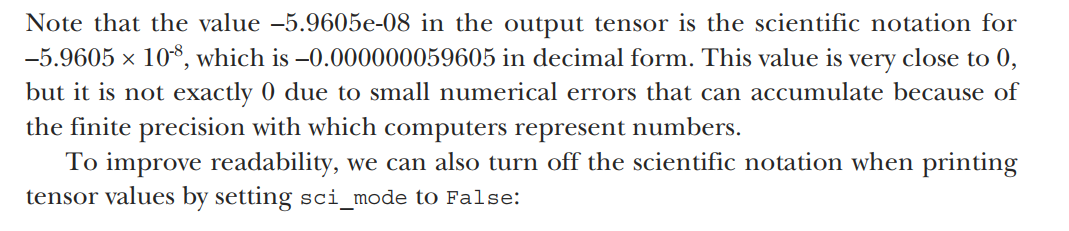

In [21]:
torch.set_printoptions(sci_mode=False)


out_norm = (out - mean) / torch.sqrt(var)
new_mean = out_norm.mean(dim = -1 , keepdim=True)
new_var = out_norm.var(dim =-1 , keepdim=True)

print(f"New Output : \n\n{out_norm}\n\n")
print(f"The new mean : \n{new_mean}\n")
print(f"The new variance : \n{new_var}\n")

New Output : 

tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)


The new mean : 
tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)

The new variance : 
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)



## Layer Normalizaion Layer

- We will add `scale` and `shift` : Two Learnable parameters
- and the model optmize them the way to decrease the loss

`scale` : is the mean

`shift` : the variance


### `unbiased = False`

- since in LLMS, the embed dim or the size is a huge 
- So we dont need to use bessel's correction `n-1`
- If embed_dim = 768, it doesnt matter much if it become 767 


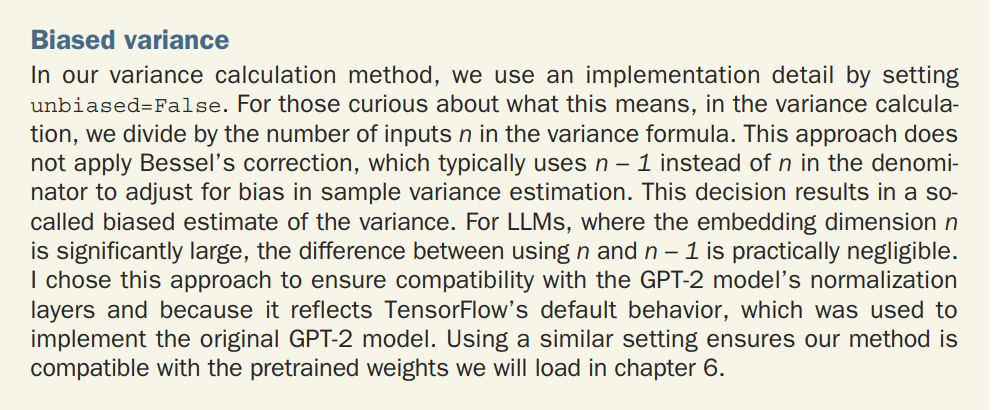



In [22]:
class NormalizationLayer(nn.Module):

    def __init__(self, embed_dim):
        super().__init__()


        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(embed_dim))
        self.shift = nn.Parameter(torch.zeros(embed_dim))

    
    def forward(self, x):

        mean = x.mean(dim= -1 , keepdim = True)
        var = x.var(dim = -1, keepdim=True, unbiased = False)

        normalized = (x - mean) / torch.sqrt(var + self.eps )

        return normalized  * self.scale + self.shift
    
    

In [23]:
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [24]:
ln = NormalizationLayer(embed_dim=5)
out_ln = ln(batch_example)

out_ln

tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)

In [25]:
print(f"Output : \n{out_ln}\n")
print(f"Mean of the output :\n\n{out_ln.mean(dim=-1 , keepdim=True)}\n\n")
print(f"Variance of the output : \n\n{out_ln.var(dim=-1 , keepdim=True , unbiased=False)}\n\n")

Output : 
tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)

Mean of the output :

tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)


Variance of the output : 

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)




# Implementing `GELU` 
- Gaussian Error Linear Unit

- Giving Better Smoothing, and thus, better optimization during Training 

## `GELU` Advantages

- Improved Performance of Deep learning Models, unlike simpler `RELU`


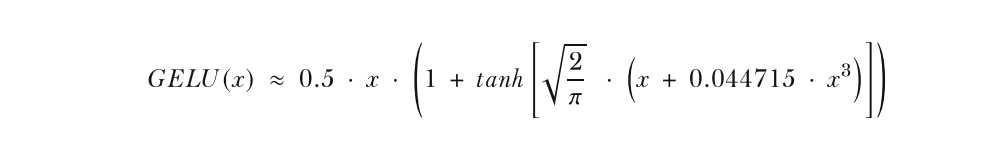

In [26]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    
    def forward(self,x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)))) * (x + 0.044715 * torch.pow(x, 3))

### See the importance of GELU 

In [27]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# create 100 points, each range from -3 & 3
x = torch.linspace(-3 , 3 ,100)
x

tensor([-3.0000, -2.9394, -2.8788, -2.8182, -2.7576, -2.6970, -2.6364, -2.5758,
        -2.5152, -2.4545, -2.3939, -2.3333, -2.2727, -2.2121, -2.1515, -2.0909,
        -2.0303, -1.9697, -1.9091, -1.8485, -1.7879, -1.7273, -1.6667, -1.6061,
        -1.5455, -1.4848, -1.4242, -1.3636, -1.3030, -1.2424, -1.1818, -1.1212,
        -1.0606, -1.0000, -0.9394, -0.8788, -0.8182, -0.7576, -0.6970, -0.6364,
        -0.5758, -0.5152, -0.4545, -0.3939, -0.3333, -0.2727, -0.2121, -0.1515,
        -0.0909, -0.0303,  0.0303,  0.0909,  0.1515,  0.2121,  0.2727,  0.3333,
         0.3939,  0.4545,  0.5152,  0.5758,  0.6364,  0.6970,  0.7576,  0.8182,
         0.8788,  0.9394,  1.0000,  1.0606,  1.1212,  1.1818,  1.2424,  1.3030,
         1.3636,  1.4242,  1.4848,  1.5455,  1.6061,  1.6667,  1.7273,  1.7879,
         1.8485,  1.9091,  1.9697,  2.0303,  2.0909,  2.1515,  2.2121,  2.2727,
         2.3333,  2.3939,  2.4545,  2.5152,  2.5758,  2.6364,  2.6970,  2.7576,
         2.8182,  2.8788,  2.9394,  3.00

In [28]:
y_gelu,y_relu = gelu(x) , relu(x)


In [29]:
for i in zip([y_gelu , y_relu] , ["Gelu" , "Relu"]):
    print(i)

(tensor([   10.4942,     9.9588,     9.4438,     8.9484,     8.4721,     8.0144,
            7.5747,     7.1525,     6.7474,     6.3586,     5.9859,     5.6287,
            5.2865,     4.9588,     4.6453,     4.3455,     4.0590,     3.7853,
            3.5241,     3.2749,     3.0375,     2.8115,     2.5964,     2.3920,
            2.1979,     2.0138,     1.8395,     1.6746,     1.5188,     1.3720,
            1.2338,     1.1040,     0.9823,     0.8686,     0.7627,     0.6643,
            0.5732,     0.4894,     0.4127,     0.3428,     0.2797,     0.2233,
            0.1734,     0.1299,     0.0928,     0.0620,     0.0375,     0.0191,
            0.0069,     0.0008,     0.0008,     0.0069,     0.0191,     0.0375,
            0.0620,     0.0928,     0.1299,     0.1734,     0.2233,     0.2797,
            0.3428,     0.4127,     0.4894,     0.5732,     0.6643,     0.7627,
            0.8686,     0.9823,     1.1040,     1.2338,     1.3720,     1.5188,
            1.6746,     1.8395,     2.0

In [30]:
for i , (y,label) in enumerate(zip([y_gelu , y_relu] , ["GELU" , "RELU"]),1):
    print()

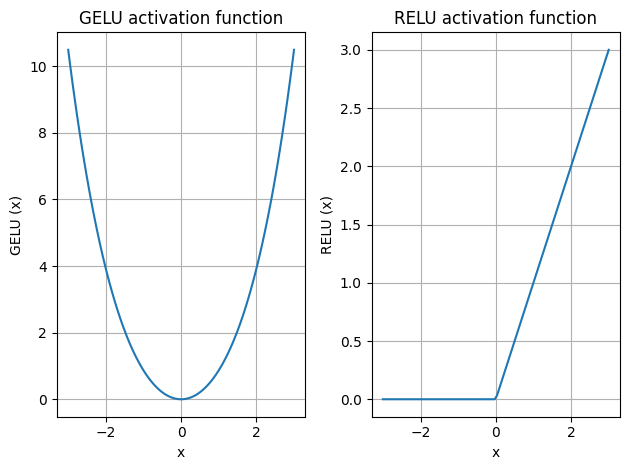

In [31]:
plt.Figure(figsize=(8,3))
for i , (y,label) in enumerate(zip([y_gelu , y_relu] , ["GELU" , "RELU"]),1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)

    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} (x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

> As we see, `GELU` is very smooth in positive and negative values 

- `GELU` : is a Non-Linear that approximate `ReLU` but with non-zero gradient at almost all negative values except at x = - 0.75 

# Implement FNN With `GELU` 

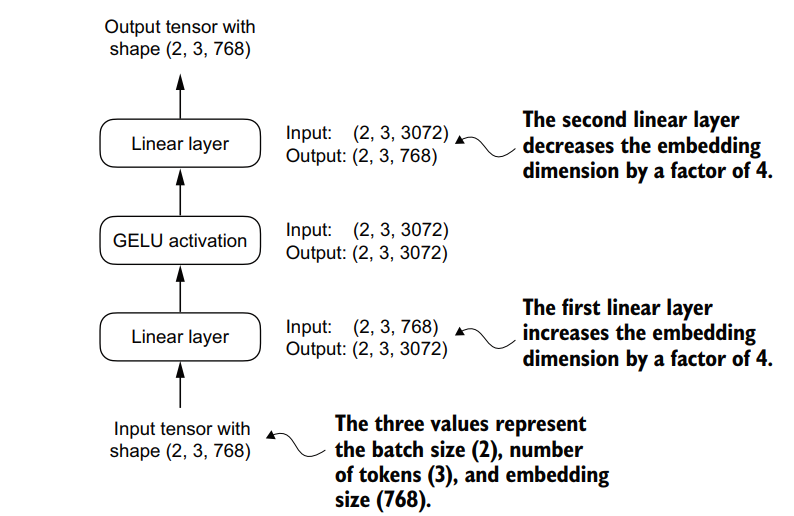

In [32]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"] , 4 *cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"] ,cfg["emb_dim"])
        )
    
    def forward (self,x):
        return self.layers(x)
    

In [33]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
print(f"x : \n{x}\n")
print(f"x Shape : \t{x.shape}")

x : 
tensor([[[0.0351, 0.0028, 0.6470,  ..., 0.5897, 0.8112, 0.1335],
         [0.2758, 0.6665, 0.3312,  ..., 0.7204, 0.3365, 0.9016],
         [0.7622, 0.4008, 0.4706,  ..., 0.4857, 0.9844, 0.0499]],

        [[0.8761, 0.8123, 0.2511,  ..., 0.8113, 0.3147, 0.6469],
         [0.9920, 0.7436, 0.7393,  ..., 0.8690, 0.1667, 0.4374],
         [0.8999, 0.0747, 0.1878,  ..., 0.0586, 0.7915, 0.8741]]])

x Shape : 	torch.Size([2, 3, 768])


In [34]:
out = ffn(x)
print(f"x : \n{out}\n")
print(f"x Shape : \t{out}")

x : 
tensor([[[ 0.0679, -0.0156,  0.0729,  ..., -0.0658,  0.0414, -0.0217],
         [ 0.0341,  0.0131,  0.1324,  ..., -0.1318, -0.0222, -0.0083],
         [ 0.1210, -0.0697,  0.0980,  ..., -0.0371,  0.0712, -0.1388]],

        [[-0.0125,  0.0434,  0.1311,  ..., -0.1011,  0.0835, -0.0569],
         [ 0.1240, -0.0348,  0.0625,  ..., -0.0414,  0.0781, -0.0349],
         [ 0.0241,  0.0305,  0.0865,  ..., -0.0473,  0.0717, -0.1349]]],
       grad_fn=<ViewBackward0>)

x Shape : 	tensor([[[ 0.0679, -0.0156,  0.0729,  ..., -0.0658,  0.0414, -0.0217],
         [ 0.0341,  0.0131,  0.1324,  ..., -0.1318, -0.0222, -0.0083],
         [ 0.1210, -0.0697,  0.0980,  ..., -0.0371,  0.0712, -0.1388]],

        [[-0.0125,  0.0434,  0.1311,  ..., -0.1011,  0.0835, -0.0569],
         [ 0.1240, -0.0348,  0.0625,  ..., -0.0414,  0.0781, -0.0349],
         [ 0.0241,  0.0305,  0.0865,  ..., -0.0473,  0.0717, -0.1349]]],
       grad_fn=<ViewBackward0>)


# Residual Network

**Skip Connection**

- Used to overcome the Vanishing Gradients Problem

## We will make a FNN with 5 layers 

- Each layer consists of `linear layer + GELU`

In [35]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes , use_shortcut):
        super().__init__()

        self.use_shortcut = use_shortcut
        self.layer_sizes = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0] , layer_sizes[1]) , GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1] , layer_sizes[2]) , GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2] , layer_sizes[3]) , GELU()),
                nn.Sequential(nn.Linear(layer_sizes[3] , layer_sizes[4]) , GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4] , layer_sizes[5]) , GELU())
            ]
        )

    def forward(self,x):
        for layer in self.layer_sizes:
            layer_output = layer(x)
            #print(f"Layer output : \n\n{layer_output}")
            #print(f"Layer output shape : {layer_output.shape}" )

            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

        

### Implemet the 5 Layers without Skipping Connections

In [36]:
torch.manual_seed(123)
layer_sizes = [3,3,3,3,3,1]
simple_input = torch.tensor([[1. , 0 , -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes , False)


In [37]:
simple_input.shape

torch.Size([1, 3])

### Implement Gradient Function 

In [38]:

def print_gradient(model,x):
    model.zero_grad()
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()


    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

        


In [39]:
print_gradient(model_without_shortcut , simple_input)

layer_sizes.0.0.weight has gradient mean of 4.587291641655611e-06
layer_sizes.1.0.weight has gradient mean of 1.979448825295549e-06
layer_sizes.2.0.weight has gradient mean of 3.9309734347625636e-06
layer_sizes.3.0.weight has gradient mean of 9.056966518983245e-06
layer_sizes.4.0.weight has gradient mean of 5.155707185622305e-05


> from the output, we can see that the `Gradients are vanishing in the first layers`

In [40]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes , True)
print_gradient(model_with_shortcut, simple_input)


layer_sizes.0.0.weight has gradient mean of 36.16075897216797
layer_sizes.1.0.weight has gradient mean of 24.417570114135742
layer_sizes.2.0.weight has gradient mean of 35.88863754272461
layer_sizes.3.0.weight has gradient mean of 27.79050064086914
layer_sizes.4.0.weight has gradient mean of 77.94564056396484


# Full Code Implementation

## Getting the `HeadAttentionTransformer` code from chapter 3 


In [41]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in , d_out, dropout ,num_heads , context_length , kqv_bias =False ):
        super().__init__()

        assert(d_out % num_heads ==0) , "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # i want the floor divison --> 512 // 8 = 64 , not for example 64.3 , i want the int


        self.w_q = nn.Linear(d_in , d_out, bias = kqv_bias)
        self.w_k = nn.Linear(d_in, d_out, bias = kqv_bias)
        self.w_v = nn.Linear(d_in, d_out, bias = kqv_bias)

        # Optional, we took different combination from the all heads together 
        self.out_proj = nn.Linear(d_out, d_out, bias =kqv_bias)

        # dropout

        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer("mask" , torch.triu(torch.ones(context_length,context_length),diagonal=1))

    

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        keys = self.w_k(x)
        queries = self.w_q(x)
        values = self.w_v(x)

        # view --> return a new tensor with the same data 
        # used to indtroduce a new dim but with keeping data as is
        # we will split d_out into (num_heads, head_dim)
            # if d_out = 512, splitting it into 8 * 64 --> giving the same 512

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        values = values.view(b, num_tokens, self.num_heads, self.head_dim)


        # transpose: used to swap `transposed` the dimensions 

        # now this becomes (b, num_heads, num_tokens , head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        attention_scores = queries @ keys.transpose(2,3)

        mask_bool = self.mask.bool()[:num_tokens , :num_tokens]

        attention_scores.masked_fill_(mask_bool, -torch.inf)


        # both are right

        #attention_weights = torch.softmax(attention_scores / self.head_dim **0.5 , dim=-1)
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] **0.5 , dim=-1)

        attention_weights = self.dropout(attention_weights)

        # returning everything at in the first place
        # return to (b, num_tokens, num_heads, head_dim)
        context_vectors = (attention_weights @ values).transpose(1,2)

        # returns to (b, num_tokens, d_out)
        context_vectors = context_vectors.contiguous().view(b, num_tokens, self.d_out)

        # final projection to get different combination

        context_vectors = self.out_proj(context_vectors)

        return context_vectors



## Implement `Transformer Block` 

- Transformer block : means Decoder Part with multi-head attention

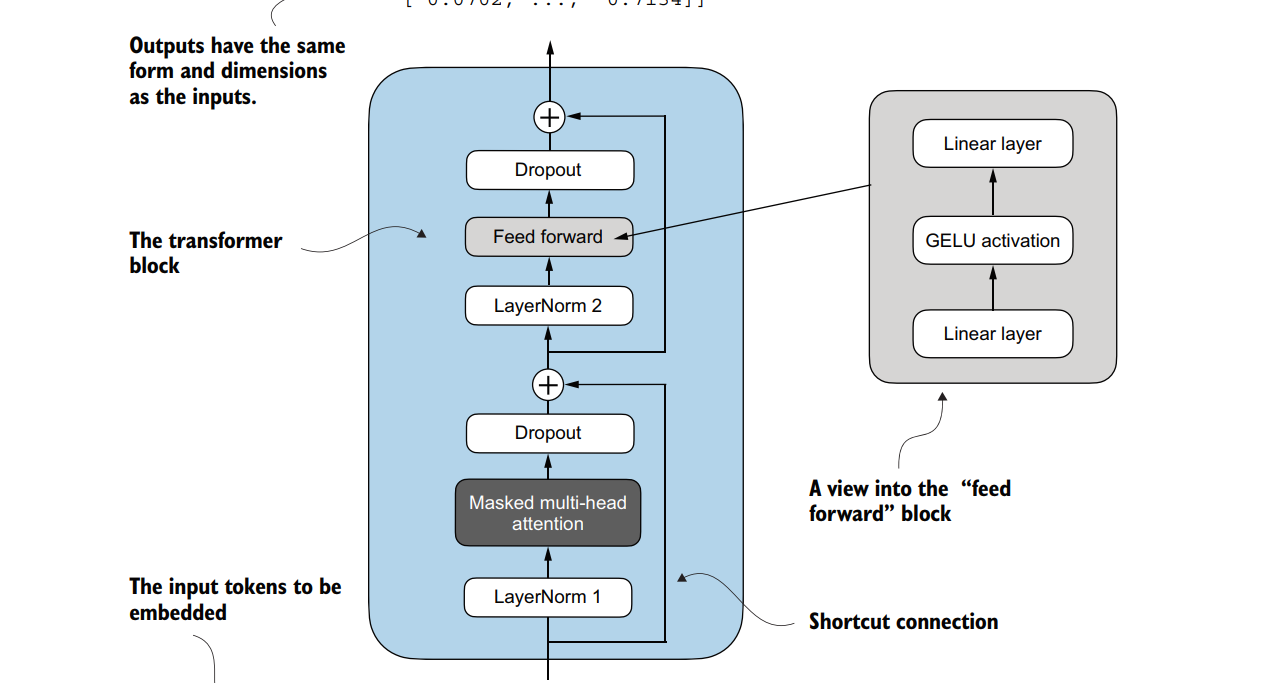

In [42]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'kqv_bias': False}

In [43]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Self attention in terms of K Q V and getting new context Vectors

        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            kqv_bias=cfg["kqv_bias"],
            num_heads=cfg["n_heads"]
        )

        # We normalize the output before passing it to fnn

        self.norm1 = NormalizationLayer(cfg["emb_dim"])

        # Pass the normalized context vectors through FNN

        self.fnn = FeedForward(cfg)

        # After passing to FNN we need to normalize it --> `more non-linearity`

        self.norm2 = NormalizationLayer(cfg["emb_dim"])

        self.dropout = nn.Dropout(cfg["drop_rate"])


    
    def forward(self,x):

        # shortcut connection for the attention block
        shortcut = x 
        x = self.norm1(x)
        x = self.att(x)
        x = self.dropout(x)
        x = x + shortcut # add the original input back to prevent vanishing

        # shortcut connection for the fnn

        # x here is the nex `x`: the output of first block of code

        shortcut = x

        x = self.norm2(x)
        x = self.fnn(x)
        x = self.dropout(x)
        x = x + shortcut



        return x
    




### Example

In [44]:
torch.manual_seed(123)
x = torch.rand(2,4,768)
block = TransformerBlock(GPT_CONFIG_124M)


output = block(x)

print(f"Output : \n\n{output}\n\n")
print(f"Output shape : {output.shape}")
print(f"Input shape :  {x.shape}")


Output : 

tensor([[[ 0.3110,  0.8534, -0.0359,  ...,  1.9204,  0.1899,  0.8613],
         [ 0.4987,  0.0210,  0.0821,  ...,  0.6656,  0.3581,  0.6493],
         [ 0.5628,  0.1070,  0.0623,  ...,  1.0411,  0.3239,  0.7905],
         [-0.3301,  0.7804,  0.3772,  ...,  1.0956,  0.2163,  0.5428]],

        [[ 0.4227,  0.5356,  0.0769,  ...,  0.5568, -0.0661, -0.0065],
         [ 0.4879,  1.0089, -0.2506,  ...,  0.6166, -0.3021,  0.1831],
         [ 0.6884, -0.2327, -0.1405,  ...,  0.8863,  0.3343, -0.3239],
         [ 0.5778,  0.5780,  0.2450,  ...,  1.4665,  0.7264, -0.6346]]],
       grad_fn=<AddBackward0>)


Output shape : torch.Size([2, 4, 768])
Input shape :  torch.Size([2, 4, 768])


# Lets Replace `GPTDummyModel` , `DummyLayerNorm`, `DummyTransformerBlock`

- With real block of code

In [45]:
class GPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.tok_embed = nn.Embedding(cfg["vocab_size"] , cfg["emb_dim"])
        self.pos_embed = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_embed = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(

            *[TransformerBlock(cfg) for _ in range (cfg["n_layers"])]
        )

        self.final_norm = NormalizationLayer(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"],bias=cfg["kqv_bias"] )



    def forward (self, in_idx):

        batch_size, seq_length = in_idx.shape

        tokenization = self.tok_embed(in_idx)
        positional_enc = self.pos_embed(torch.arange(seq_length, device=in_idx.device))

        # Now the embeddings become = positional encoding + embeddings
        embeddings = tokenization + positional_enc

        # Dropout

        x = self.drop_embed(embeddings)

        # passing the embeddings to the decoders

        x = self.trf_blocks(x)

        # Layer Normalization

        x = self.final_norm(x)

        # Final Logits

        logits = self.out_head(x)

        return logits
    
    

In [46]:
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [47]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out=  model(batch)

print(f"Input shape : {batch.shape}")
print(f"Output shape : {out.shape}")
print(f"Output :\n{out}\n")

Input shape : torch.Size([2, 4])
Output shape : torch.Size([2, 4, 50257])
Output :
tensor([[[-0.6946, -0.3232,  0.2884,  ..., -0.2200, -0.1817, -0.5887],
         [-0.4349, -0.4422, -0.6639,  ...,  0.4946, -0.2117, -0.6189],
         [-0.2720,  0.4757, -0.2653,  ...,  0.3519,  0.0074,  0.6050],
         [-0.4464, -0.2820,  0.8859,  ...,  0.4897,  0.3037,  0.7111]],

        [[-1.1708, -0.4107, -0.0405,  ...,  0.1582, -0.1939, -0.5970],
         [-0.5706, -0.1640, -0.4374,  ..., -0.5503, -0.4759,  0.0581],
         [-0.6363,  0.4433, -0.2766,  ..., -0.1351, -0.2893,  0.2189],
         [-0.5606, -0.5751,  0.5956,  ...,  0.6831,  0.4115,  0.0054]]],
       grad_fn=<UnsafeViewBackward0>)



# Calc the `GPT` Parameters

### `numel` : Counts Number of elements

In [48]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163000320

In [49]:
print(f"Total number of parameters in the model : {total_params:,}")

Total number of parameters in the model : 163,000,320


In [50]:
model

GPTModel(
  (tok_embed): Embedding(50257, 768)
  (pos_embed): Embedding(1024, 768)
  (drop_embed): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=False)
        (w_k): Linear(in_features=768, out_features=768, bias=False)
        (w_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): NormalizationLayer()
      (fnn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm2): NormalizationLayer()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (w_q): Linear(in_f

In [51]:
print(f"Token embedding layer shape: {model.tok_embed.weight.shape}")
print(f"Output layer shape : {model.out_head.weight.shape}")

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape : torch.Size([50257, 768])


## Compute Memory requirement

- For `163M` Parameters

In [52]:

total_size_bytes = total_params * 4  # Assuming 4 bytes per parameter (float32)
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total model size in MB : {total_size_mb:.2f} MB")


Total model size in MB : 621.80 MB


# Generate Text from `GPT Model`

In [68]:
x = torch.rand(10,4)
x

tensor([[0.7680, 0.8238, 0.5876, 0.1103],
        [0.0232, 0.0760, 0.1201, 0.0849],
        [0.6602, 0.1702, 0.1545, 0.3267],
        [0.3101, 0.3395, 0.1058, 0.6142],
        [0.8754, 0.3330, 0.8236, 0.2535],
        [0.7105, 0.0492, 0.1259, 0.0365],
        [0.7280, 0.6292, 0.8112, 0.6381],
        [0.7439, 0.1890, 0.8426, 0.3023],
        [0.6868, 0.1928, 0.6103, 0.2123],
        [0.5235, 0.6572, 0.7437, 0.1710]])

In [64]:
x = torch.tensor([12,54,1231,546,46,1245,23,123])
x

tensor([  12,   54, 1231,  546,   46, 1245,   23,  123])

In [99]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print(f"Encoded : {encoded}")
print(f"Encoded shape : {len(encoded)}")

Encoded : [15496, 11, 314, 716]
Encoded shape : 4


In [100]:
# Adding Batch dimension
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(f"Encoded : {encoded_tensor}")
print(f"Encoded Shape : {encoded_tensor.shape}")

Encoded : tensor([[15496,    11,   314,   716]])
Encoded Shape : torch.Size([1, 4])


#### 1. get the last max_tokens 

- because if the model has encoded ids more thean the context_length --> we cut the last max_tokens

In [78]:
encoded_tensor[:,-2:]

tensor([[314, 716]])

### 2. Generate Logits based on the last context_size

In [80]:
logits = model(encoded_tensor)
logits

tensor([[[-1.3477, -0.2890, -0.1472,  ..., -1.0494, -0.0859, -0.6738],
         [-0.5520, -0.1054, -0.8650,  ..., -0.4629, -0.6519, -0.5992],
         [-0.5400,  0.1177, -0.5778,  ..., -0.3783, -0.2998,  0.2644],
         [-0.6090, -0.6190, -0.1091,  ...,  0.0558,  0.6227,  0.1316]]],
       grad_fn=<UnsafeViewBackward0>)

In [81]:
logits.shape

torch.Size([1, 4, 50257])

#### 3. Geting the last token

- leave all batches
- Select last row
- leave all columns

In [89]:
logits = logits[:, -1, :]
logits

tensor([[-0.6090, -0.6190, -0.1091,  ...,  0.0558,  0.6227,  0.1316]],
       grad_fn=<SliceBackward0>)

### 4. Getting the probability

- Using Softmax

In [93]:
proba = torch.softmax(logits, dim = -1)
proba

tensor([[    0.0000,     0.0000,     0.0000,  ...,     0.0000,     0.0000,
             0.0000]], grad_fn=<SoftmaxBackward0>)

### 5. get the highest token id

- using `argmax`

In [94]:
idx_next = torch.argmax(proba,dim =-1, keepdim=True)
idx_next

tensor([[37738]])

### 6. Adding the highest token id with the existing tokens

In [95]:
idx = torch.cat((encoded_tensor,idx_next) , dim=1)
idx

tensor([[15496,    11,   314,   716, 37738]])

## Generate text function

**Collecting all the previous steps**


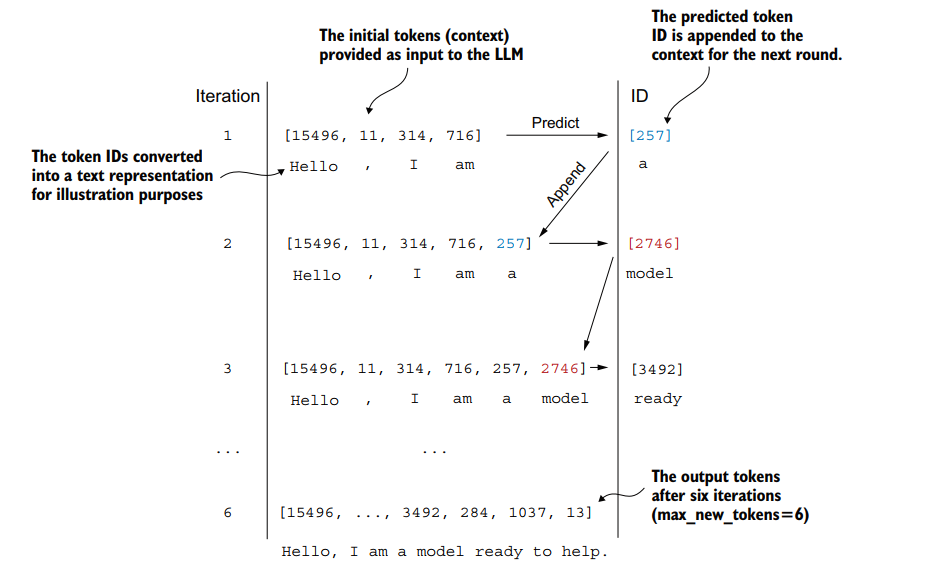

In [96]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size :]

        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1,]
        probas = torch.softmax(logits, dim= -1)
        idx_next = torch.argmax(probas, dim = -1 , keepdim=True)
        idx = torch.cat((idx_cond, idx_next) , dim=1)
    return idx

## Put the model into `.eval()`

- This mode, disables the `dropout` 

In [102]:
model.eval()
out = generate_text_simple(
    model = model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(f"Output : {out}")
print(f"Output Length : {len(out[0])}")

Output : tensor([[15496,    11,   314,   716, 37738, 15043,  8307, 24649,  1749, 33753]])
Output Length : 10


In [106]:
out.squeeze(0).shape

torch.Size([10])

In [107]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())

decoded_text

'Hello, I amELF permanently Attack memoirories Ober'